In [1]:
import os
import json
import joblib

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from skimage.feature import hog

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
train_dir = r"C:\Users\Ali\Downloads\archive\brisc2025\classification_task\train"
test_dir = r"C:\Users\Ali\Downloads\archive\brisc2025\classification_task\test"

In [ ]:
print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))

Train folder exists: True
Test folder exists: True


In [ ]:
classes = sorted([
    folder
    for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Classes:", classes)

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [ ]:
label_map = {
    class_name: index
    for index, class_name in enumerate(classes)
}

print("Label Mapping:")
print(label_map)

Label Mapping:
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [ ]:
print("Training Dataset:")

for cls in classes:
    folder = os.path.join(train_dir, cls)
    count = len(os.listdir(folder))
    print(cls, ":", count)

Training Dataset:
glioma : 1147
meningioma : 1329
no_tumor : 1067
pituitary : 1457


In [ ]:
print("Testing Dataset:")

for cls in classes:
    folder = os.path.join(test_dir, cls)
    count = len(os.listdir(folder))
    print(cls, ":", count)

Testing Dataset:
glioma : 254
meningioma : 306
no_tumor : 140
pituitary : 300


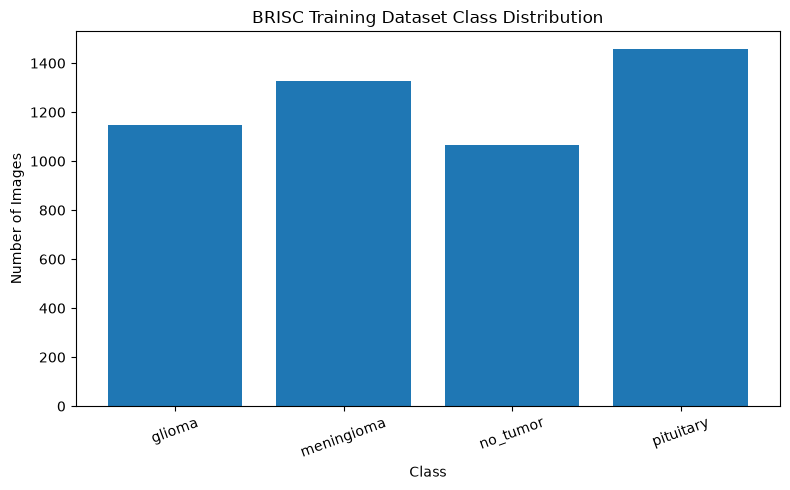

In [ ]:
train_counts = []

for cls in classes:
    folder = os.path.join(train_dir, cls)
    train_counts.append(len(os.listdir(folder)))

plt.figure(figsize=(8, 5))
plt.bar(classes, train_counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("BRISC Training Dataset Class Distribution")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

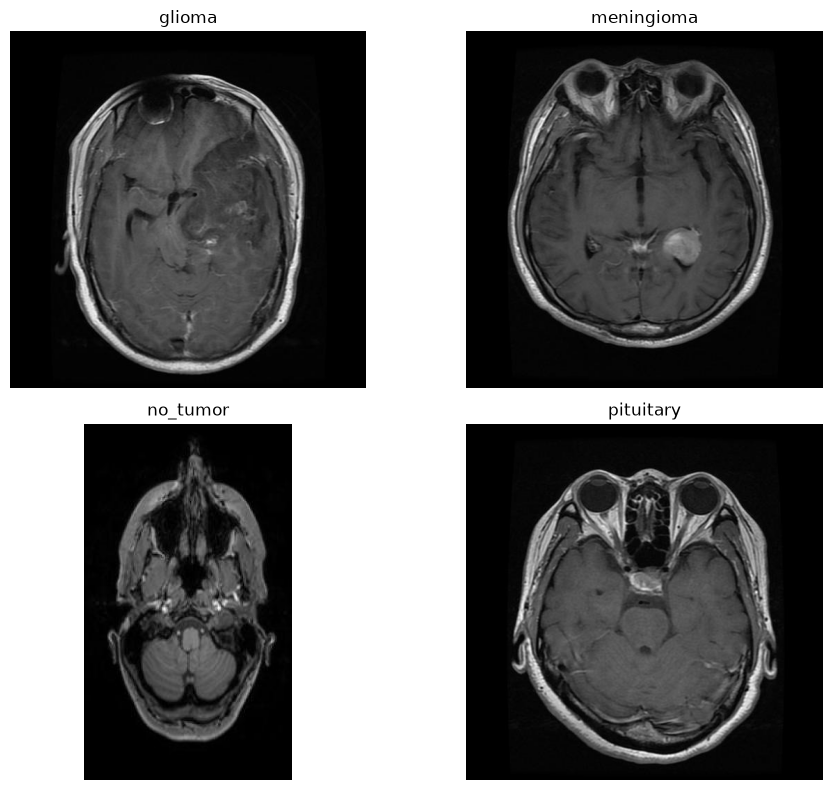

In [ ]:
plt.figure(figsize=(10, 8))

for i, cls in enumerate(classes):

    folder = os.path.join(train_dir, cls)

    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def preprocess_image(image_path):

    image = Image.open(image_path)

    # Convert to grayscale
    image = image.convert("L")

    # Resize
    image = image.resize((128, 128))

    # Convert to NumPy array
    image = np.array(image)

    # Normalize pixel values
    image = image / 255.0

    # Extract HOG features
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )

    return features

In [ ]:
sample_class = classes[0]

sample_folder = os.path.join(train_dir, sample_class)

sample_image_name = os.listdir(sample_folder)[0]

sample_image_path = os.path.join(
    sample_folder,
    sample_image_name
)

features = preprocess_image(sample_image_path)

print("Sample image:", sample_image_path)
print("Feature shape:", features.shape)

Sample image: C:\Users\Ali\Downloads\archive\brisc2025\classification_task\train\glioma\brisc2025_train_00001_gl_ax_t1.jpg
Feature shape: (8100,)


In [ ]:
X_train = []
y_train = []

for class_name in classes:

    class_folder = os.path.join(train_dir, class_name)

    print("Processing:", class_name)

    for image_name in os.listdir(class_folder):

        image_path = os.path.join(
            class_folder,
            image_name
        )

        try:
            features = preprocess_image(image_path)

            X_train.append(features)
            y_train.append(label_map[class_name])

        except Exception as e:
            print(
                "Error:",
                image_path,
                "|",
                type(e).__name__,
                "|",
                e
            )

X_train = np.array(X_train)
y_train = np.array(y_train)

print("\nTraining complete.")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Processing: glioma
Processing: meningioma
Processing: no_tumor
Processing: pituitary

Training complete.
X_train shape: (5000, 8100)
y_train shape: (5000,)


In [ ]:
X_test = []
y_test = []

for class_name in classes:

    class_folder = os.path.join(test_dir, class_name)

    print("Processing:", class_name)

    for image_name in os.listdir(class_folder):

        image_path = os.path.join(
            class_folder,
            image_name
        )

        try:
            features = preprocess_image(image_path)

            X_test.append(features)
            y_test.append(label_map[class_name])

        except Exception as e:
            print(
                "Error:",
                image_path,
                "|",
                type(e).__name__,
                "|",
                e
            )

X_test = np.array(X_test)
y_test = np.array(y_test)

print("\nTesting complete.")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Processing: glioma
Processing: meningioma
Processing: no_tumor
Processing: pituitary

Testing complete.
X_test shape: (1000, 8100)
y_test shape: (1000,)


In [ ]:
print("Training samples:", len(X_train))
print("Training labels:", len(y_train))

print("Testing samples:", len(X_test))
print("Testing labels:", len(y_test))

print("Training NaN:", np.isnan(X_train).any())
print("Testing NaN:", np.isnan(X_test).any())

Training samples: 5000
Training labels: 5000
Testing samples: 1000
Testing labels: 1000
Training NaN: False
Testing NaN: False


In [ ]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

print("Original features:", X_train.shape[1])
print("Reduced features:", X_train_pca.shape[1])

Original features: 8100
Reduced features: 1485


In [ ]:
knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 7]
}

grid = GridSearchCV(
    knn,
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

print("Best K:", grid.best_params_["n_neighbors"])
print("Best Cross-Validation Macro F1:", grid.best_score_)

Best K: 5
Best Cross-Validation Macro F1: 0.6162550473000477


In [ ]:
best_knn = grid.best_estimator_

y_pred_knn = best_knn.predict(X_test_pca)

Final KNN Accuracy: 89.1 %

Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.88      0.91       254
  meningioma       0.88      0.75      0.81       306
    no_tumor       0.93      0.99      0.96       140
   pituitary       0.85      0.99      0.92       300

    accuracy                           0.89      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.89      0.89      0.89      1000



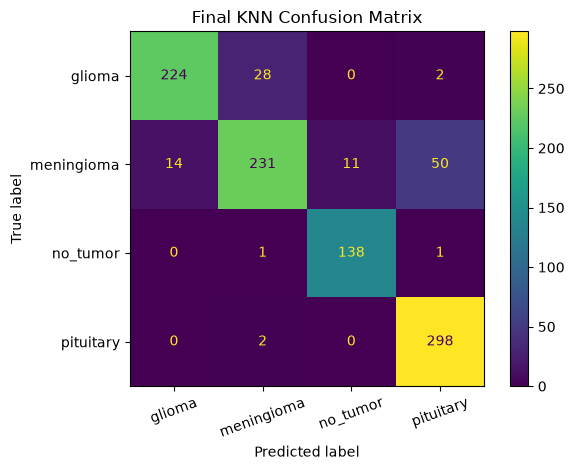

In [ ]:
final_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print(
    "Final KNN Accuracy:",
    final_accuracy * 100,
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=classes,
        zero_division=0
    )
)

cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=classes
)

disp.plot()

plt.title("Final KNN Confusion Matrix")
plt.xticks(rotation=20)
plt.tight_layout()

# Save the same figure
os.makedirs("../results", exist_ok=True)

plt.savefig(
    "../results/knn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

knn_results = {
    "Model": "KNN",
    "Best K": grid.best_params_["n_neighbors"],
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Macro Precision": precision_score(
        y_test,
        y_pred_knn,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_test,
        y_pred_knn,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_test,
        y_pred_knn,
        average="macro",
        zero_division=0
    )
}

knn_results

{'Model': 'KNN',
 'Best K': 5,
 'Accuracy': 0.891,
 'Macro Precision': 0.8995083013870891,
 'Macro Recall': 0.9039598359028651,
 'Macro F1': 0.898620320338302}

In [ ]:
os.makedirs("../results", exist_ok=True)

In [ ]:
os.makedirs("../features", exist_ok=True)

np.save(
    "../features/X_train_pca.npy",
    X_train_pca
)

np.save(
    "../features/X_test_pca.npy",
    X_test_pca
)

np.save(
    "../features/y_train.npy",
    y_train
)

np.save(
    "../features/y_test.npy",
    y_test
)

In [ ]:
joblib.dump(
    pca,
    "../features/pca_model.pkl"
)

['../features/pca_model.pkl']

In [ ]:
joblib.dump(
    best_knn,
    "../features/knn_model.pkl"
)

['../features/knn_model.pkl']

In [ ]:
with open(
    "../features/label_map.json",
    "w"
) as f:

    json.dump(
        label_map,
        f,
        indent=4
    )

In [ ]:
print(knn_results)

{'Model': 'KNN', 'Best K': 5, 'Accuracy': 0.891, 'Macro Precision': 0.8995083013870891, 'Macro Recall': 0.9039598359028651, 'Macro F1': 0.898620320338302}


In [ ]:
import os

print(os.listdir("../features"))

['knn_model.pkl', 'label_map.json', 'pca_model.pkl', 'X_test_pca.npy', 'X_train_pca.npy', 'y_test.npy', 'y_train.npy']
